# Breast Cancer Detection Neural Network

In [47]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torch import nn
from sklearn.metrics import classification_report, confusion_matrix

## Load Training Data

The preprocessed and standardized training data is loaded from `data/processedData/`. These CSVs were generated by the data preprocessor notebook, which applied standardization ($z = \frac{x - \mu}{\sigma}$) and an 80/20 stratified split (455 training, 114 test samples).

In [48]:
X = pd.read_csv("../data/processedData/X_train_scaled.csv", index_col=0).values
Y = pd.read_csv("../data/processedData/Y_train.csv", index_col=0).values

## Convert to Tensors

The pandas DataFrames are converted to PyTorch `float32` tensors. Labels are reshaped to a column vector `(-1, 1)` to match the single-output network. The best available device (GPU if available, otherwise CPU) is then selected and all data is moved to it.

In [49]:
X_tensor = torch.tensor(X, dtype=torch.float32)
Y_tensor = torch.tensor(Y, dtype=torch.float32).view(-1, 1)

In [50]:
device = "cuda" if torch.cuda.is_available() else "cpu"
X_tensor = X_tensor.to(device)
Y_tensor = Y_tensor.to(device)
print(f"Using device: {device}")

Using device: cpu


## Neural Network Architecture

A three-layer fully connected network with ReLU activations. The final layer outputs a single raw **logit** (no activation) — `BCEWithLogitsLoss` fuses the sigmoid internally for numerical stability.

```
Input (30) → Linear(30 → 512) → ReLU → Linear(512 → 512) → ReLU → Linear(512 → 1) → logit
```

In [51]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(30, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 1)
        )

    def forward(self, x):
        return self.linear_relu_stack(x)

## Model Initialization

Instantiate the network and move it to the selected device.

In [52]:
model = NeuralNetwork().to(device)
print(model)

NeuralNetwork(
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=30, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=1, bias=True)
  )
)


### Pre-Training Sanity Check

Before training, we verify the untrained model produces reasonable random predictions. With random weights, accuracy near 50–65% (the majority-class rate) is expected.

In [54]:
# Sanity check: accuracy of the untrained model before training begins
with torch.no_grad():
    init_logits = model(X_tensor)
    init_probs = torch.sigmoid(init_logits)
    init_preds = (init_probs > 0.5).float()
    init_correct = (init_preds == Y_tensor).sum().item()
    init_accuracy = init_correct / len(Y_tensor)
    print(f"Pre-training accuracy: {init_accuracy:.4f}")

Pre-training accuracy: 0.6022


## Training Setup

We use **Binary Cross-Entropy with Logits** (`BCEWithLogitsLoss`) as the loss function — it combines sigmoid + BCE in one numerically stable operation. The **Adam** optimizer is used with a learning rate of `0.001`.

In [55]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## Training Loop

The model is trained for 500 epochs using full-batch gradient descent. The loss for every epoch is recorded in `losses` for the convergence plot below.

In [56]:
epochs = 500
losses = []

for epoch in range(epochs):
    optimizer.zero_grad()
    logits = model(X_tensor)
    loss = loss_fn(logits, Y_tensor)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if epoch % 50 == 0:
        print(f"Epoch {epoch}/{epochs},  Loss: {loss.item():.4f}")

Epoch 0/500,  Loss: 0.7038
Epoch 50/500,  Loss: 0.0131
Epoch 100/500,  Loss: 0.0014
Epoch 150/500,  Loss: 0.0005
Epoch 200/500,  Loss: 0.0002
Epoch 250/500,  Loss: 0.0001
Epoch 300/500,  Loss: 0.0001
Epoch 350/500,  Loss: 0.0001
Epoch 400/500,  Loss: 0.0001
Epoch 450/500,  Loss: 0.0000


### Training Loss Curve

A steadily decreasing loss confirms the model is learning. If the loss plateaus early, try reducing the learning rate or adding regularization (e.g., dropout).

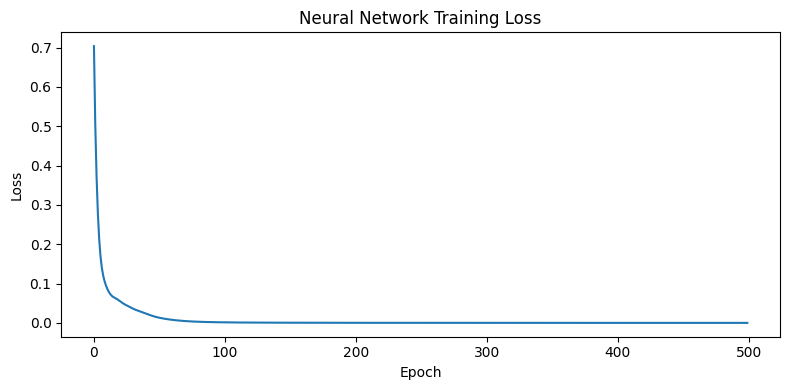

In [57]:
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Neural Network Training Loss")
plt.tight_layout()
plt.show()

## Load Test Data

Load the held-out test split and convert to tensors on the same device as the model.

In [58]:
X_test = pd.read_csv("../data/processedData/X_test_scaled.csv", index_col=0).values
Y_test = pd.read_csv("../data/processedData/Y_test.csv", index_col=0).values

X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
Y_test_tensor = torch.tensor(Y_test, dtype=torch.float32).view(-1, 1).to(device)

## Evaluate on Test Set

Run inference on the test set with `torch.no_grad()` (disables gradient tracking for efficiency) and report accuracy. This measures how well the trained model generalizes to unseen samples.

In [59]:
with torch.no_grad():
    test_logits = model(X_test_tensor)
    test_pred_probab = torch.sigmoid(test_logits)
    test_predictions = (test_pred_probab > 0.5).float()
    test_correct = (test_predictions == Y_test_tensor).sum().item()
    test_accuracy = test_correct / len(Y_test_tensor)
    print(f"Test Accuracy: {test_accuracy:.4f}")

# Convert to numpy for sklearn metrics
y_true = Y_test_tensor.cpu().numpy().ravel().astype(int)
y_pred = test_predictions.cpu().numpy().ravel().astype(int)

Test Accuracy: 0.9561


### Classification Report

Precision, recall, and F1-score per class. **Recall for the malignant class (1) is the most critical metric** — a false negative (missed cancer) is more dangerous than a false positive.

In [60]:
print(classification_report(y_true, y_pred, target_names=["Benign (0)", "Malignant (1)"]))

               precision    recall  f1-score   support

   Benign (0)       0.95      0.99      0.97        72
Malignant (1)       0.97      0.90      0.94        42

     accuracy                           0.96       114
    macro avg       0.96      0.95      0.95       114
 weighted avg       0.96      0.96      0.96       114



### Confusion Matrix

Rows = actual class, columns = predicted class. The bottom-left cell (actual Malignant, predicted Benign) is the **false negative** count — the most important number to minimize in cancer detection.

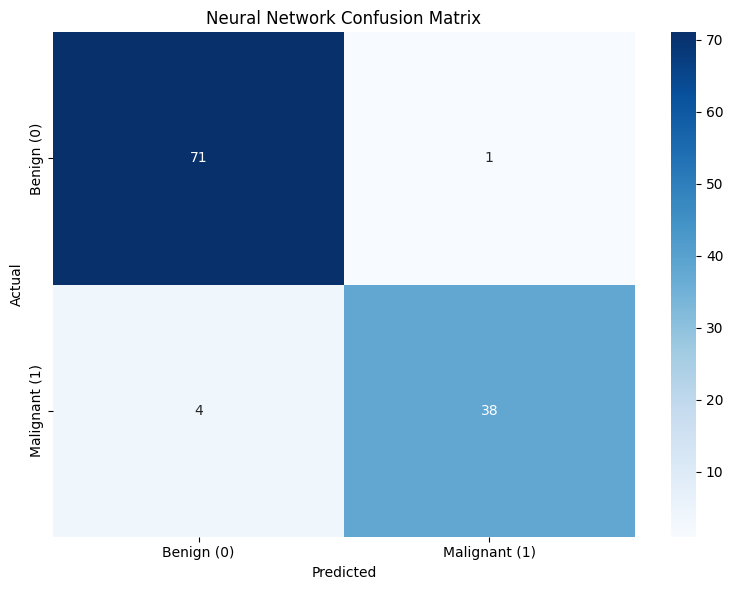

In [61]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign (0)", "Malignant (1)"],
    yticklabels=["Benign (0)", "Malignant (1)"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Neural Network Confusion Matrix")
plt.tight_layout()
plt.show()

In [62]:
import os, numpy as np

os.makedirs("../data/models", exist_ok=True)
np.savetxt("../data/models/nn_predictions.csv", y_pred, delimiter=",", fmt="%d")
print("Saved nn_predictions.csv")

Saved nn_predictions.csv
